In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")


pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv("/Users/sodex/Documents/Amdari Projects/NEXYGEN/ESG_Data.csv", parse_dates=["Date"])

In [4]:
df

,Date,Year,Asset_ID,Asset_Type,Location,Operational_Status,Energy_Type,Consumption_Units,Emission_Type,Emissions_tCO2e,Target_Emissions_tCO2e,Reduction_Percentage_vs_BaseYear
0,2020-01-01,2020,A001,ServiceHub,England,Active,ELECTRICITY_KWH,2357.044,Scope 1,0.645377,15004.345,0.00
1,2020-01-01,2020,A001,ServiceHub,England,Active,ELECTRICITY_KWH,2357.044,Scope 2,0.530871,15004.345,0.00
2,2020-01-02,2020,A001,ServiceHub,England,Active,ELECTRICITY_KWH,2440.574,Scope 1,0.688000,15004.345,0.00
3,2020-01-02,2020,A001,ServiceHub,England,Active,ELECTRICITY_KWH,2440.574,Scope 2,0.572372,15004.345,0.00
4,2020-01-03,2020,A001,ServiceHub,England,Active,ELECTRICITY_KWH,2396.825,Scope 1,0.715998,15004.345,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
236731,2025-12-29,2025,A018,Depot,England,Active,DIESEL_L,220.770,Scope 2,0.140224,11307.747,24.64
236732,2025-12-30,2025,A018,Depot,England,Active,DIESEL_L,186.620,Scope 1,0.699935,11307.747,24.64
236733,2025-12-30,2025,A018,Depot,England,Active,DIESEL_L,186.620,Scope 2,0.149179,11307.747,24.64
236734,2025-12-31,2025,A018,Depot,England,Active,DIESEL_L,155.839,Scope 1,0.593795,11307.747,24.64


# Data Examination

Checked for Null Values

Checked for Duplicates

In [5]:
# check for Data information and null values
print(f"Dataset shape: {df.shape}")
print(f"Date Range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Data Info: {df.info()}\n")

#Check for duplicates
print(f"Duplicates: {df.duplicated().sum()}\n")
print(f"key_duplicates: {df.duplicated(subset=['Date','Asset_ID', 'Energy_Type']).sum()}")

Dataset shape: (236736, 12)
Date Range: 2020-01-01 00:00:00 to 2025-12-31 00:00:00
<class 'pandas.DataFrame'>
RangeIndex: 236736 entries, 0 to 236735
Data columns (total 12 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   Date                              236736 non-null  datetime64[us]
 1   Year                              236736 non-null  int64         
 2   Asset_ID                          236736 non-null  str           
 3   Asset_Type                        236736 non-null  str           
 4   Location                          236736 non-null  str           
 5   Operational_Status                236736 non-null  str           
 6   Energy_Type                       236736 non-null  str           
 7   Consumption_Units                 236736 non-null  float64       
 8   Emission_Type                     236736 non-null  str           
 9   Emissions_tCO2e                

In [6]:
# Task 1: Check for Cardinality of the dataset. Include code to show the categories with the number of unique categories
for col in df.columns:
    unique_values = df[col].nunique()
    print(f"{col}: {unique_values} \n")

Date: 2192 

Year: 6 

Asset_ID: 18 

Asset_Type: 5 

Location: 3 

Operational_Status: 1 

Energy_Type: 3 

Consumption_Units: 114751 

Emission_Type: 2 

Emissions_tCO2e: 77329 

Target_Emissions_tCO2e: 6 

Reduction_Percentage_vs_BaseYear: 6 



# Task 2: 

### Check for Distribution using histogram


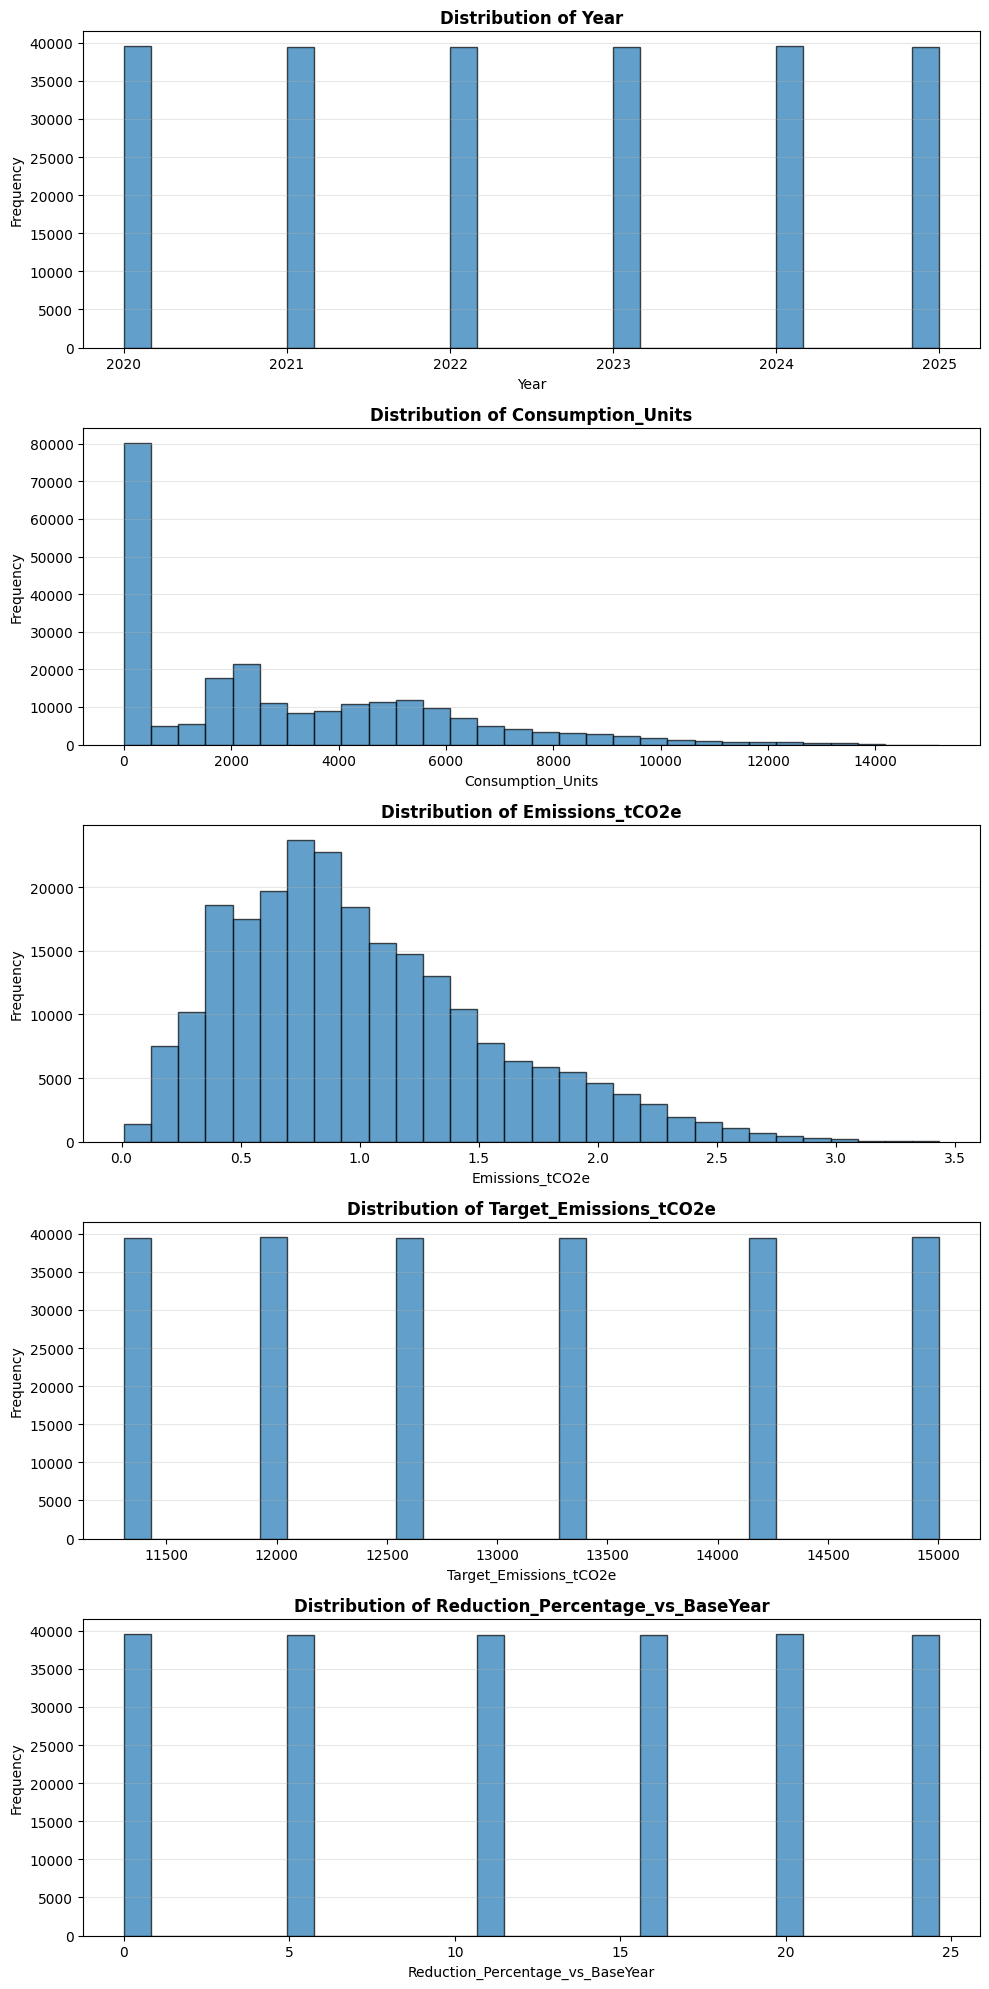

Histograms created for 5 numerical columns: ['Year', 'Consumption_Units', 'Emissions_tCO2e', 'Target_Emissions_tCO2e', 'Reduction_Percentage_vs_BaseYear']


In [8]:
# Check for Distribution use histograms for numerical columns and bar charts for categorical columns. 
# Include code to show the distribution of the data and identify any skewness or outliers.

import matplotlib.pyplot as plt
import seaborn as sns

# Get numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns

# Create a figure with subplots for distribution histograms
fig, axes = plt.subplots(len(numerical_cols), 1, figsize=(10, 4*len(numerical_cols)))

# Flatten axes array if there's only one subplot
if len(numerical_cols) == 1:
    axes = [axes]

# Plot histogram for each numerical column
for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Histograms created for {len(numerical_cols)} numerical columns: {list(numerical_cols)}")

# Check for outliers using box plots
# The box plots will display:
 - Median (red line in the center)
 - Quartiles (the box boundaries showing 25th and 75th percentiles)
 - Whiskers (extend to 1.5× IQR from quartiles)
 - Outliers (data points beyond the whiskers)
 Get numerical columns

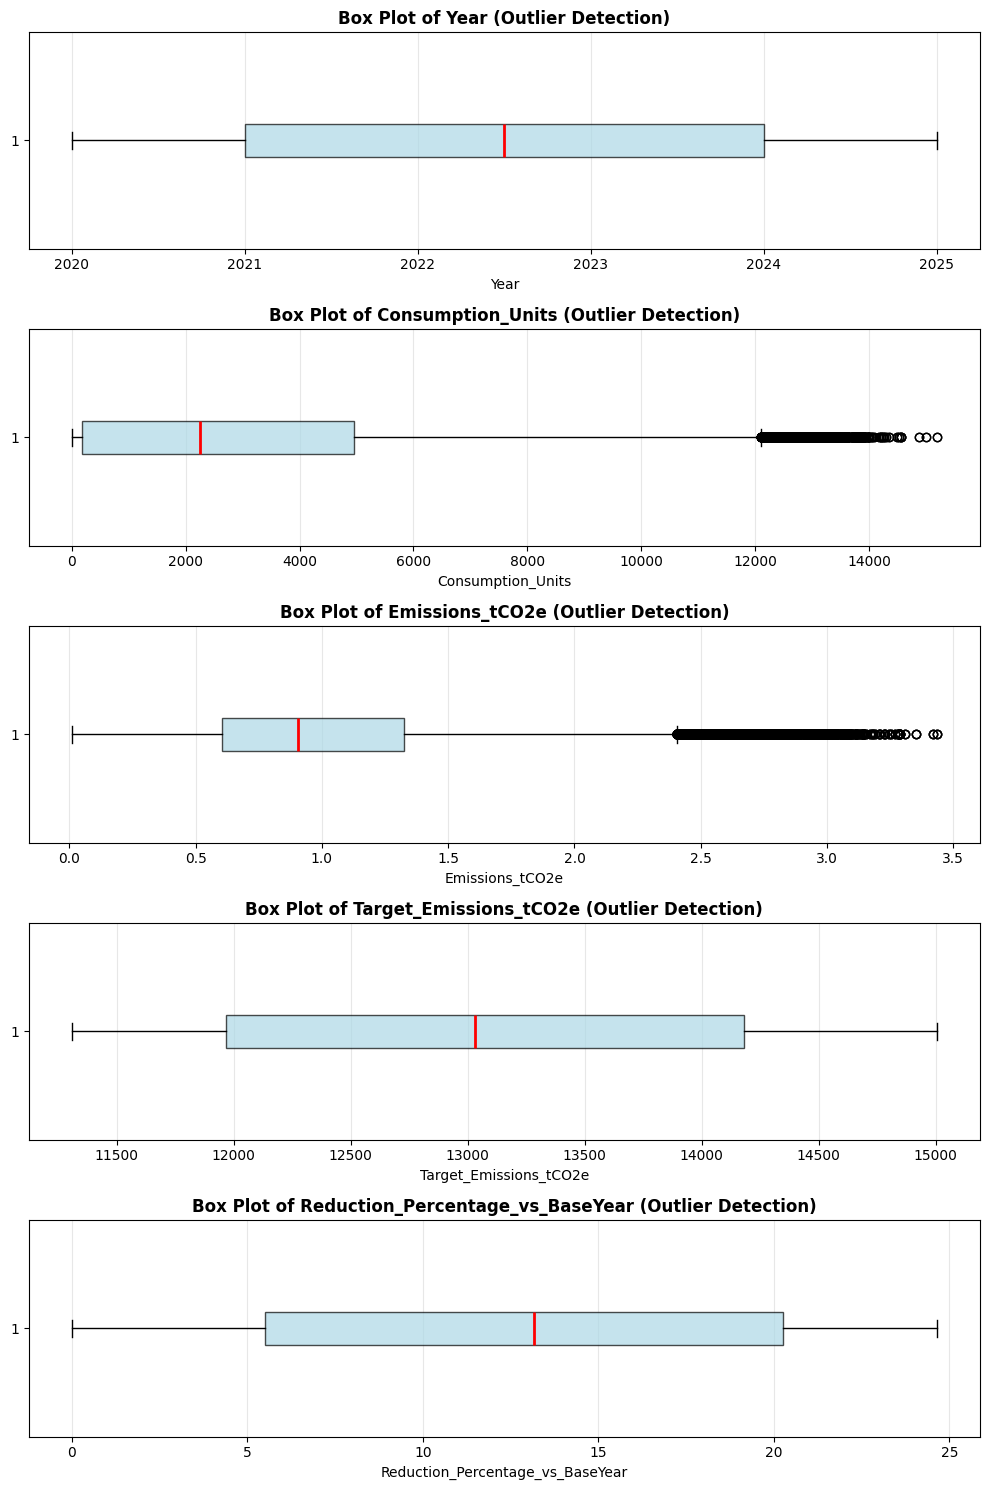

Box plots created for 5 numerical columns: ['Year', 'Consumption_Units', 'Emissions_tCO2e', 'Target_Emissions_tCO2e', 'Reduction_Percentage_vs_BaseYear']


In [9]:
# Check for outliers using box plots

numerical_cols = df.select_dtypes(include=[np.number]).columns

# Create box plots for each numerical column
fig, axes = plt.subplots(len(numerical_cols), 1, figsize=(10, 3*len(numerical_cols)))

# Flatten axes array if there's only one subplot
if len(numerical_cols) == 1:
    axes = [axes]

# Plot box plot for each numerical column
for idx, col in enumerate(numerical_cols):
    axes[idx].boxplot(df[col].dropna(), vert=False, patch_artist=True,
                      boxprops=dict(facecolor='lightblue', alpha=0.7),
                      medianprops=dict(color='red', linewidth=2))
    axes[idx].set_title(f'Box Plot of {col} (Outlier Detection)', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Box plots created for {len(numerical_cols)} numerical columns: {list(numerical_cols)}")

### Compute basic statistics to further understand our data i.e mean, median, STD Deviation, skewness, kurtosis; can use formulars or functions, .describe 

all these for numerical values

In [10]:
# Compute basic statistics: mean, median, std deviation, skewness, kurtosis
from scipy import stats

# Get numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns

print("="*80)
print("BASIC STATISTICAL SUMMARY")
print("="*80)

# Using .describe() for quick overview
print("\n1. Standard Descriptive Statistics (.describe()):\n")
print(df[numerical_cols].describe())

# Compute additional statistics
print("\n" + "="*80)
print("2. Additional Statistics (Skewness & Kurtosis):\n")

stats_summary = pd.DataFrame({
    'Mean': df[numerical_cols].mean(),
    'Median': df[numerical_cols].median(),
    'Std_Deviation': df[numerical_cols].std(),
    'Skewness': df[numerical_cols].skew(),
    'Kurtosis': df[numerical_cols].kurtosis()
})

print(stats_summary)

# Interpretation guide
print("\n" + "="*80)
print("INTERPRETATION GUIDE:")
print("="*80)
print("Skewness:")
print("  • ~0: Symmetric distribution")
print("  • > 0: Right-skewed (tail on right)")
print("  • < 0: Left-skewed (tail on left)")
print("\nKurtosis:")
print("  • ~0: Normal distribution (mesokurtic)")
print("  • > 0: Heavy tails, more outliers (leptokurtic)")
print("  • < 0: Light tails, fewer outliers (platykurtic)")
print("="*80)

BASIC STATISTICAL SUMMARY

1. Standard Descriptive Statistics (.describe()):

                Year  Consumption_Units  Emissions_tCO2e  \
count  236736.000000      236736.000000    236736.000000   
mean     2022.499544        2974.985016         1.011650   
std         1.708185        2913.827113         0.552706   
min      2020.000000           2.132000         0.009922   
25%      2021.000000         189.146500         0.605021   
50%      2022.500000        2251.237000         0.906257   
75%      2024.000000        4954.110250         1.324795   
max      2025.000000       15188.331000         3.434222   

       Target_Emissions_tCO2e  Reduction_Percentage_vs_BaseYear  
count           236736.000000                     236736.000000  
mean             13086.800251                         12.780908  
std               1263.214803                          8.419583  
min              11307.747000                          0.000000  
25%              11965.870000                      

# Exploratory Data Analysis

Emission_Type
Scope 1    131129.696790
Scope 2    108364.355412
Name: Emissions_tCO2e, dtype: float64


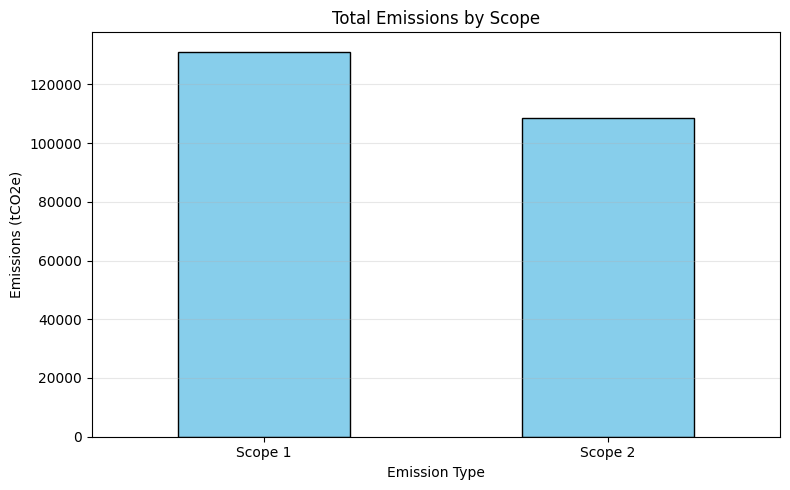

In [16]:
emission_by_scope = df.groupby('Emission_Type')['Emissions_tCO2e'].sum()

emission_by_scope.plot(kind='bar', figsize=(8, 5), color='skyblue', edgecolor='black')

## Daily Emissions Trend

Daily emissions trend for Scope 1 and Scope 2.

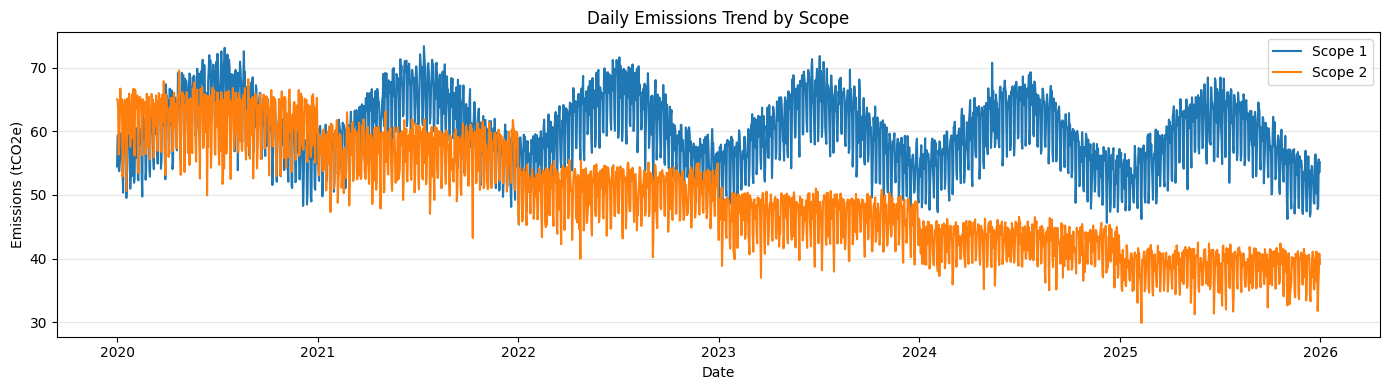

In [ ]:
# Daily emissions by type (robust label matching)

daily_emissions = (
    df.groupby(['Date', 'Emission_Type'])['Emissions_tCO2e']
    .sum()
    .reset_index()
)

# Normalize labels to avoid case/space mismatches
daily_emissions['Emission_Type_norm'] = (
    daily_emissions['Emission_Type'].astype(str).str.strip().str.lower()
)

fig, ax = plt.subplots(figsize=(14, 4))
for scope in ['scope 1', 'scope 2']:
    data = daily_emissions[daily_emissions['Emission_Type_norm'] == scope].sort_values('Date')
    ax.plot(data['Date'], data['Emissions_tCO2e'], label=scope.title())

ax.set_title('Daily Emissions Trend by Scope')
ax.set_xlabel('Date')
ax.set_ylabel('Emissions (tCO2e)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Monthly Emissions Trend

Monthly emissions trend for Scope 1 and Scope 2.

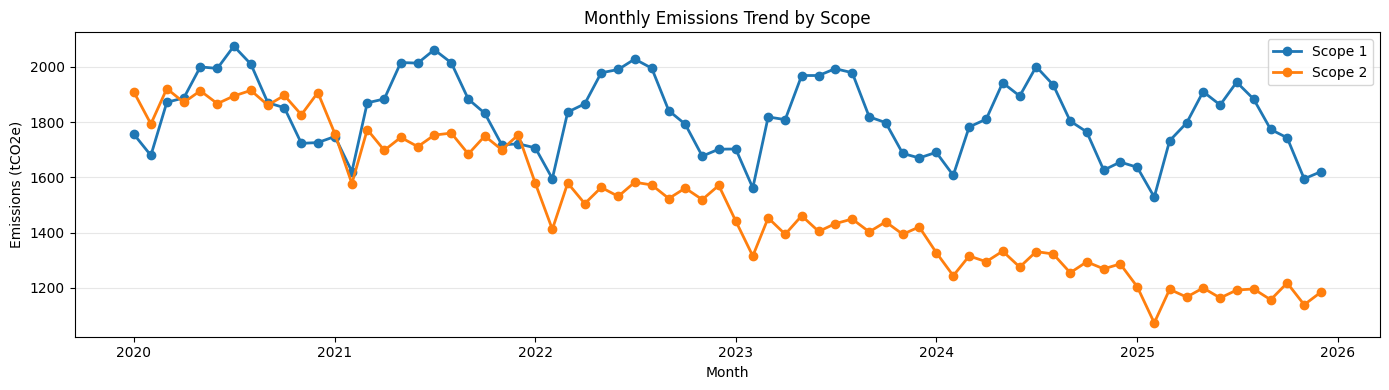

In [ ]:
# Monthly emissions by type (robust label matching)
monthly_emissions = (df.groupby([pd.Grouper(key='Date', freq='MS'), 'Emission_Type'])['Emissions_tCO2e']
    .sum().reset_index())

monthly_emissions['Emission_Type_norm'] = (monthly_emissions['Emission_Type'].astype(str).str.strip().str.lower())

fig, ax = plt.subplots(figsize=(14, 4))
for scope in ['scope 1', 'scope 2']:
    data = monthly_emissions[monthly_emissions['Emission_Type_norm'] == scope].sort_values('Date')
    ax.plot(data['Date'], data['Emissions_tCO2e'], marker='o', linewidth=2, label=scope.title())

ax.set_title('Monthly Emissions Trend by Scope')
ax.set_xlabel('Month')
ax.set_ylabel('Emissions (tCO2e)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Yearly Emissions Trend

Yearly emissions trend for Scope 1 and Scope 2.

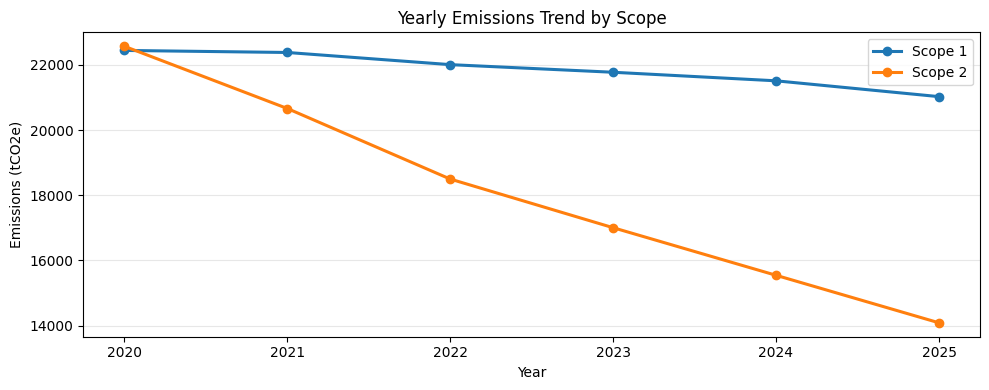

In [31]:
# Yearly emissions by type (robust label matching)
yearly_emissions = (
    df.groupby([pd.Grouper(key='Date', freq='YS'), 'Emission_Type'])['Emissions_tCO2e']
    .sum()
    .reset_index()
)

yearly_emissions['Emission_Type_norm'] = (
    yearly_emissions['Emission_Type'].astype(str).str.strip().str.lower()
)

fig, ax = plt.subplots(figsize=(10, 4))
for scope in ['scope 1', 'scope 2']:
    data = yearly_emissions[yearly_emissions['Emission_Type_norm'] == scope].sort_values('Date')
    ax.plot(data['Date'], data['Emissions_tCO2e'], marker='o', linewidth=2.2, label=scope.title())

ax.set_title('Yearly Emissions Trend by Scope')
ax.set_xlabel('Year')
ax.set_ylabel('Emissions (tCO2e)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Yearly Emissions vs Target Comparison

Compare yearly total emissions to yearly target emissions (using first target value per year).

   Year  Emissions_tCO2e  Target_Emissions_tCO2e
0  2020     45013.034982               15004.345
1  2021     43037.987178               14179.106
2  2022     40501.973178               13399.255
3  2023     38776.663731               12662.296
4  2024     37055.604741               11965.870
5  2025     35108.788392               11307.747


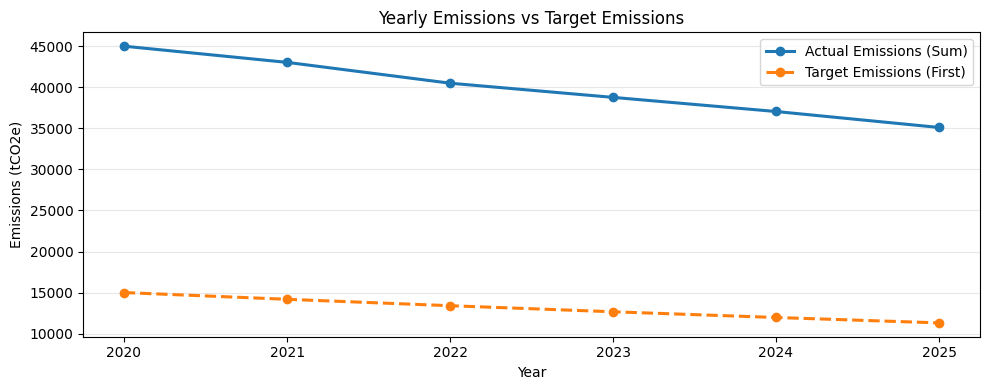

In [32]:
# Aggregate by year: emissions as sum, target emissions as first value in each year
yearly_compare = (
    df.groupby(pd.Grouper(key='Date', freq='YS'))
      .agg({
          'Emissions_tCO2e': 'sum',
          'Target_Emissions_tCO2e': 'first'
      })
      .reset_index()
)

# Display aggregated table
yearly_compare['Year'] = yearly_compare['Date'].dt.year
print(yearly_compare[['Year', 'Emissions_tCO2e', 'Target_Emissions_tCO2e']])

# Plot actual vs target trend
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    yearly_compare['Date'],
    yearly_compare['Emissions_tCO2e'],
    marker='o',
    linewidth=2.2,
    label='Actual Emissions (Sum)'
)
ax.plot(
    yearly_compare['Date'],
    yearly_compare['Target_Emissions_tCO2e'],
    marker='o',
    linewidth=2.2,
    linestyle='--',
    label='Target Emissions (First)'
)

ax.set_title('Yearly Emissions vs Target Emissions')
ax.set_xlabel('Year')
ax.set_ylabel('Emissions (tCO2e)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Seasonality analysis to determine the type of forcasting model to use.